In [1]:
import numpy as np
import pandas as pd
import random as rd
import seaborn as sns
import matplotlib.pyplot as plt
from math import sqrt
from scipy.optimize import basinhopping, minimize
import time
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid", {'axes.grid' : False})
plt.rcParams['font.family'] = ['Microsoft YaHei','Arial']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 定义目标函数 
eps = 1e-6

def objective(x):
    p1, p2 = x
    if c <= p1 and p1 <= u1:
        r1 = (p1-c)*(u1-p1)/(1-p1)
    else:
        r1 = 0
    if c <= p2 and p2 <= u2:
        r2 = (p2-c)*(u2-p2)/(1-p2)
    else:
        r2 = 0
    R = r1 + r2
    return -R - eps * (p2 - p1)  # 最大化加 -

# 约束条件
def constraint1(x):
    # p1 >= c
    return x[0] - c

def constraint2(x):
    # 1 >= p2
    return 1 - x[1]

def constraint3(x):
    # p2 >= p1 
    return x[1] - x[0]

def constraint4(x):
    # p2 - p1 <= delta
    return delta - (x[1] - x[0])

# 约束字典
constraints = [
    {'type': 'ineq', 'fun': constraint1},  # 默认>=0
    {'type': 'ineq', 'fun': constraint2},
    {'type': 'ineq', 'fun': constraint3},
    {'type': 'ineq', 'fun': constraint4}
]

# 2. p2* > μ1

第1次试验
最优p1: 0.178416
最优p2: 0.178416
p之差: 0.000000
最大利润: 0.013665


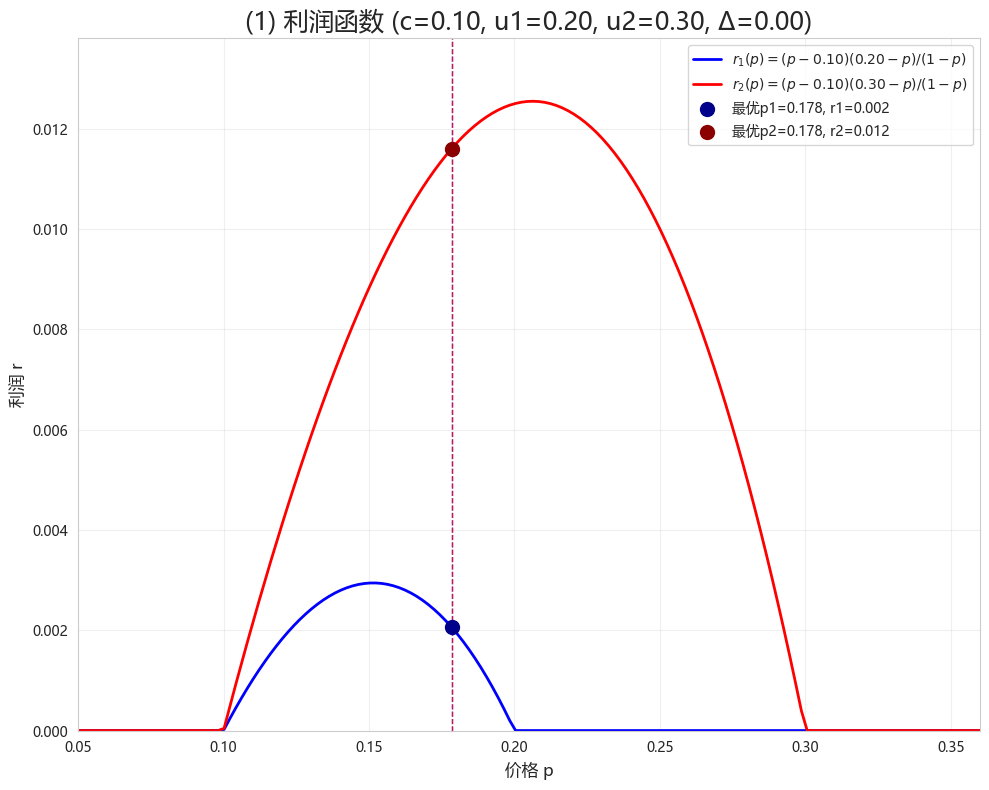

In [4]:
## 0 ##
c  = 0.1
u1 = 0.2
u2 = 0.3

for i in range(1):
#     c = rd.random()  # [0, 1)
#     u1 = c + (1 - c) * rd.random() 
#     u2 = 1- (1-u1)**2/(1-c) + rd.random() * (1-u1)**2/(1-c)  #  *p2 > u1
#     c = rd.randint(0, 7)
#     u1 = rd.randint(c+1, 8)
#     u2 = rd.randint(u1+1, 9) * 0.1
#     c *= 0.1
#     u1 *= 0.1
#     delta = (u2 - c) * rd.random()
#     if u2 <= 1-(1-u1)**2/(1-c):
#         continue
#     cond_1 = u1 - 1 + sqrt((1-c)*(2-u1-u2)/2)
#     RT = (2 - 2*c - u1 + c*u1 - u2 + c*u2)
#     cond_2 = sqrt(2) * (1 - c - RT/sqrt(2)) * (-2 + sqrt(2)*RT + u1 + u2) / RT  \
#              - (sqrt(1-c)-sqrt(1-u2))**2
#     if cond_1 <= 0 or cond_2 <= 0:  # 忽略跳跃情况
#         continue
    delta = 0
    bounds = [(c, u2), (c, u2)]
    initial_guess = np.array([(c+u1)/2, (c+u2)/2])

    result = minimize(objective, initial_guess, 
                 bounds=bounds, 
                 constraints=constraints, 
                 method='SLSQP',
                 tol=1e-12,           # 收敛容忍度
                 options={'ftol': 1e-12,  # 函数值变化的容忍度
                          'eps': 1e-8,    # 有限差分步长
                          'maxiter': 1000, # 最大迭代次数
                          'disp': False}   # 显示优化过程信息
            )

    optimal_p1, optimal_p2 = result.x
    max_profit = -result.fun

    print(f'第{i+1}次试验')
    print(f"最优p1: {optimal_p1:.6f}")
    print(f"最优p2: {optimal_p2:.6f}")
    print(f"p之差: {optimal_p2-optimal_p1:.6f}")
    print(f"最大利润: {max_profit:.6f}")
#     print(f"c: {c:.6f}，delta: {delta:.6f}")
#     print(f"u1: {u1:.6f}, u2: {u2:.6f}")
#     if optimal_p1 > u1:
#         print("存在牺牲1类客户利润情况.")

    plt.figure(figsize=(10, 8))
    p_values = np.linspace(0, 1, 500)  # 生成数据点
    r1_values = []
    r2_values = []
    for p in p_values:
        if c <= p <= u1:
            r1 = (p-c)*(u1-p)/(1-p)
        else:
            r1 = 0
        if c <= p <= u2:
            r2 = (p-c)*(u2-p)/(1-p)
        else:
            r2 = 0
        r1_values.append(r1)
        r2_values.append(r2)
    # 绘制r1和r2曲线
    plt.plot(p_values, r1_values, label=f'$r_1(p) = (p-{c:.2f})({u1:.2f}-p)/(1-p)$', linewidth=2, color='blue')
    plt.plot(p_values, r2_values, label=f'$r_2(p) = (p-{c:.2f})({u2:.2f}-p)/(1-p)$', linewidth=2, color='red')
    # 计算最优点的函数值
    if c <= optimal_p1 <= u1:
        optimal_r1 = (optimal_p1-c)*(u1-optimal_p1)/(1-optimal_p1)
    else:
        optimal_r1 = 0
    if c <= optimal_p2 <= u2:
        optimal_r2 = (optimal_p2-c)*(u2-optimal_p2)/(1-optimal_p2)
    else:
        optimal_r2 = 0
    plt.scatter(optimal_p1, optimal_r1, s=100, color='darkblue', marker='o', 
               label=f'最优p1={optimal_p1:.3f}, r1={optimal_r1:.3f}', zorder=5)
    plt.scatter(optimal_p2, optimal_r2, s=100, color='darkred', marker='o', 
               label=f'最优p2={optimal_p2:.3f}, r2={optimal_r2:.3f}', zorder=5)
    # 添加垂直线标记最优价格
    plt.axvline(x=optimal_p1, color='blue', linestyle='--', alpha=0.7, linewidth=1)
    plt.axvline(x=optimal_p2, color='red', linestyle='--', alpha=0.7, linewidth=1)
    plt.xlabel('价格 p', fontsize=12)
    plt.ylabel('利润 r', fontsize=12)
    plt.title(f'({i+1}) 利润函数 (c={c:.2f}, u1={u1:.2f}, u2={u2:.2f}, Δ={delta:.2f})', fontsize=18)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim(0.5*c, 1.2*u2)
    plt.ylim(0, max(r2_values) * 1.1)
    plt.tight_layout()
    plt.show()

# 3. 随Δ变化

In [4]:
Profits = []
opt_p1 = []
opt_p2 = []

num = 300
deltas = np.linspace(start=0, stop=num/1000, num=num)
start = time.time()
print('正在进行实验……')

for i in range(num):
    delta = deltas[i]            # 0.3 * i / num
    bounds = [(c, u2), (c, u2)]
    initial_guess = np.array([(c+u1)/2, (c+u2)/2])
#     result = minimize(objective, initial_guess, 
#              bounds=bounds, 
#              constraints=constraints, 
#              method='SLSQP',
#              tol=1e-12,                # 收敛容忍度
#              options={'ftol': 1e-12,   # 函数值变化容忍度
#                       'eps': 1e-8,     # 有限差分步长
#                       'maxiter': 1000, # 最大迭代次数
#                       'disp': False}   # 显示优化过程信息
#             )
    result = basinhopping(objective, initial_guess, niter=200,
                     minimizer_kwargs={'method': 'SLSQP', 
                                     'bounds': bounds,
                                     'constraints': constraints,
                                     'options': {'ftol': 1e-8}})
    optimal_p1, optimal_p2 = result.x
    max_profit = -result.fun
    Profits.append(max_profit)
    opt_p1.append(optimal_p1)
    opt_p2.append(optimal_p2)
    
#     result = minimize(objective, initial_guess, 
#                  bounds=bounds, 
#                  constraints=constraints, 
#                  method='COBYLA',
#                  options={'tol': 1e-10, 'maxiter': 2000})
#                  method='trust-constr',
#                  options={'gtol': 1e-8, 'xtol': 1e-8, 'maxiter': 1000, 'disp': False}
#                 )
time_cost = time.time() - start
print(f'{num}次实验结束,用时:{time_cost:.2f}s')

正在进行实验……
300次实验结束,用时:378.59s


# 4. 均匀分布

In [5]:
## 1 ## 定义目标函数（均匀分布）
def objective_uniform(x):
    p1, p2 = x
    if c <= p1 <= 2*u1:
        r1 = (p1-c)*(1-p1/(2*u1))
#     if c <= p1 <= 1:
#         if p1 >= 2*u1-1:
#             r1 = (p1-c)*(1-p1)/(2-2*u1)
#         else:
#             r1 = p1 - c
    else:
        r1 = 0
    if c <= p2 <= 2*u2:
        r2 = (p2-c)*(1-p2/(2*u2))
#     if c <= p2 <= 1:
#         if p2 >= 2*u2-1:
#             r2 = (p2-c)*(1-p2)/(2-2*u2)
#         else:
#             r2 = p2 - c
    else:
        r2 = 0
    return -(r1 + r2) - eps * (p2 - p1)  # 最大化加 -

def constraint1(x):
    # p1 >= c
    return x[0] - c

def constraint2(x):
    # 1 >= p2
    return 1 - x[1]

def constraint3(x):
    # p2 >= p1
    return x[1] - x[0]

def constraint4(x):
    # p2 - p1 <= delta
    return delta - (x[1] - x[0])

constraints = [
    {'type': 'ineq', 'fun': constraint1},  # 默认>=0
    {'type': 'ineq', 'fun': constraint2},
    {'type': 'ineq', 'fun': constraint3},
    {'type': 'ineq', 'fun': constraint4}
]

最优p1: 0.250000
最优p2: 0.450000
p之差: 0.200001
最大利润: 0.209375


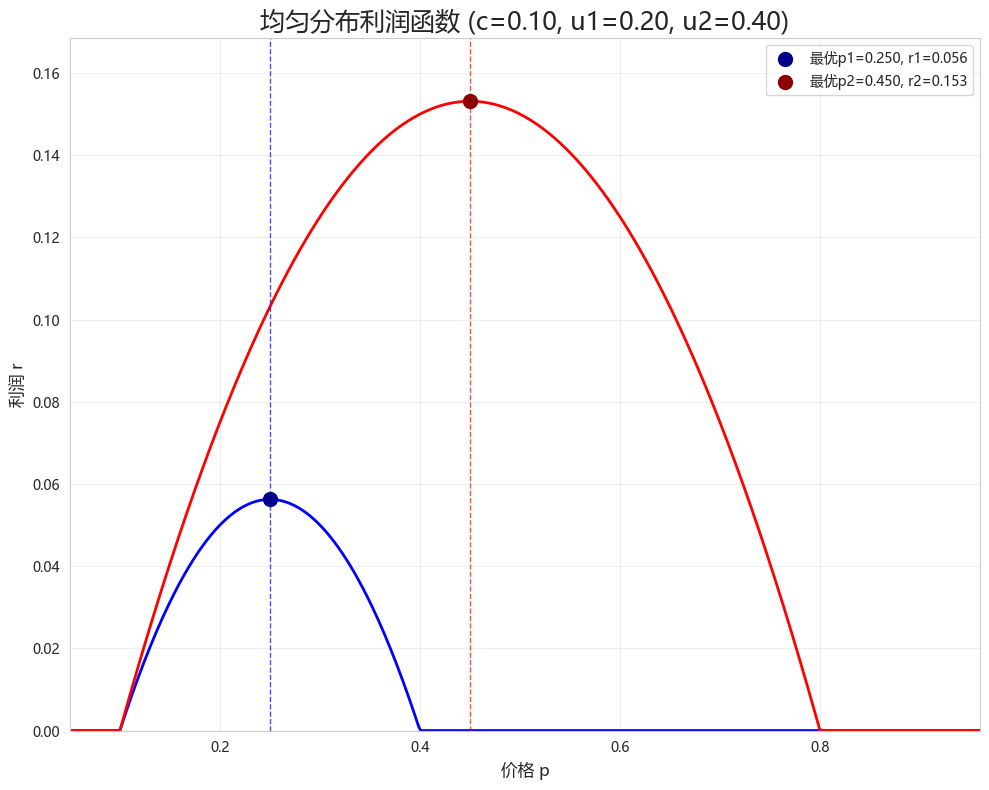

In [6]:
# 均匀分布利润函数
delta = 1 - c
bounds = [(c, 1), (c, 1)]
initial_guess = np.array([(c+2*u1)/2, (c+2*u2)/2])

result = minimize(objective_uniform, initial_guess, 
             bounds=bounds, 
             constraints=constraints, 
             method='SLSQP',
             tol=1e-12,           # 收敛容忍度
             options={'ftol': 1e-12,  # 函数值变化的容忍度
                      'eps': 1e-8,    # 有限差分步长
                      'maxiter': 1000, # 最大迭代次数
                      'disp': False}   # 显示优化过程信息
            )

optimal_p1, optimal_p2 = result.x
max_profit = -result.fun

print(f"最优p1: {optimal_p1:.6f}")
print(f"最优p2: {optimal_p2:.6f}")
print(f"p之差: {optimal_p2-optimal_p1:.6f}")
print(f"最大利润: {max_profit:.6f}")

plt.figure(figsize=(10, 8))
p_values = np.linspace(0, 1, 500)
r1_value = []
r2_value = []

## 2 ##
for p in p_values:
    if c <= p <= 2*u1:
        r1 = (p-c)*(1-p/(2*u1))
#     if c <= p <= 1:
#         if p >= 2*u1-1:
#             r1 = (p-c)*(1-p)/(2-2*u1)
#         else:
#             r1 = p - c
    else:
        r1 = 0
    if c <= p <= 2*u2:
        r2 = (p-c)*(1-p/(2*u2))
#     if c <= p <= 1:
#         if p >= 2*u2-1:
#             r2 = (p-c)*(1-p)/(2-2*u2)
#         else:
#             r2 = p - c
    else:
        r2 = 0
    r1_value.append(r1)
    r2_value.append(r2)

plt.plot(p_values, r1_value, linewidth=2, color='blue')  #, label=f'$r_1(p) = (p-{c:.1f})(1-p)/{2-2*u1:.1f}$'
plt.plot(p_values, r2_value, linewidth=2, color='red')  #, label=f'$r_2(p) = (p-{c:.1f})(1-p)/{2-2*u2:.1f}$'

## 3 ##
if c <= optimal_p1 <= 2*u1:
    optimal_r1 = (optimal_p1-c)*(1-optimal_p1/(2*u1))
# if c <= optimal_p1 <= 1:
#     optimal_r1 = (optimal_p1-c)*(1-optimal_p1)/(2-2*u1)
else:
    optimal_r1 = 0
if c <= optimal_p2 <= 2*u2:
    optimal_r2 = (optimal_p2-c)*(1-optimal_p2/(2*u2))
# if c <= optimal_p2 <= 1:
#     optimal_r2 = (optimal_p2-c)*(1-optimal_p2)/(2-2*u2)
else:
    optimal_r2 = 0
    
plt.scatter(optimal_p1, optimal_r1, s=100, color='darkblue', marker='o', 
           label=f'最优p1={optimal_p1:.3f}, r1={optimal_r1:.3f}', zorder=5)
plt.scatter(optimal_p2, optimal_r2, s=100, color='darkred', marker='o', 
           label=f'最优p2={optimal_p2:.3f}, r2={optimal_r2:.3f}', zorder=5)
plt.axvline(x=optimal_p1, color='blue', linestyle='--', alpha=0.7, linewidth=1)
plt.axvline(x=optimal_p2, color='red', linestyle='--', alpha=0.7, linewidth=1)
plt.xlabel('价格 p', fontsize=12)
plt.ylabel('利润 r', fontsize=12)
plt.title(f'均匀分布利润函数 (c={c:.2f}, u1={u1:.2f}, u2={u2:.2f})', fontsize=18)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0.5*c, 1.2*2*u2)
plt.ylim(0, max(r2_value) * 1.1)
plt.tight_layout()
plt.show()

In [7]:
unif_p1 = []
unif_p2 = []

print('正在进行实验……')
for i in range(num):
    delta = deltas[i]
    bounds = [(c, 1), (c, 1)]
    initial_guess = np.array([(c+2*u1)/2, (c+2*u2)/2])
    result = minimize(objective_uniform, initial_guess, 
             bounds=bounds, 
             constraints=constraints, 
             method='SLSQP',
             tol=1e-12,               # 收敛容忍度
             options={'ftol': 1e-12,  # 函数值变化的容忍度
                      'eps': 1e-8,    # 有限差分步长
                      'maxiter': 1000,# 最大迭代次数
                      'disp': False}  # 显示优化过程信息
        )
    optimal_p1, optimal_p2 = result.x
    max_profit = -result.fun
    unif_p1.append(optimal_p1)
    unif_p2.append(optimal_p2)
print(f'{num}次实验结束')

正在进行实验……
300次实验结束


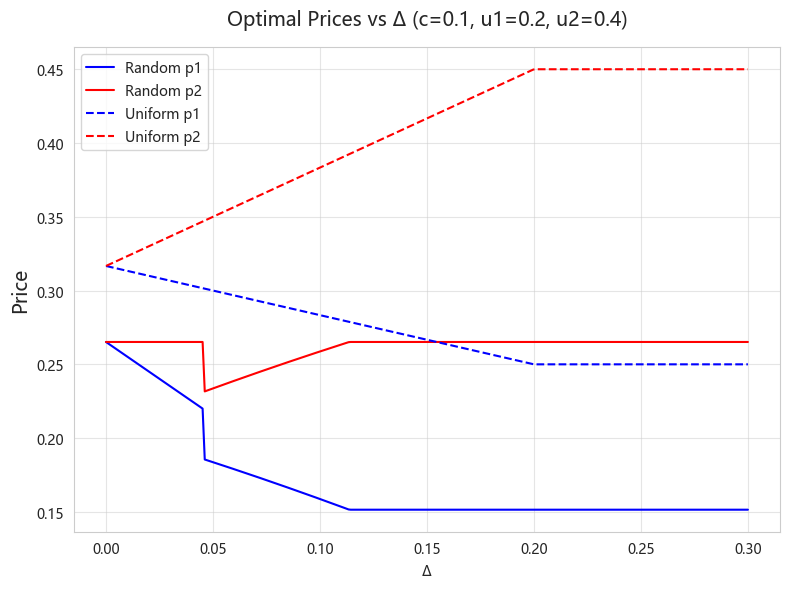

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(deltas, opt_p1, alpha=1, color="blue", label='Random p1')
plt.plot(deltas, opt_p2, alpha=1, color="red", label='Random p2')
plt.plot(deltas, unif_p1, alpha=1, color="blue", linestyle='--', label='Uniform p1')
plt.plot(deltas, unif_p2, alpha=1, color="red", linestyle='--', label='Uniform p2')
plt.title(f"Optimal Prices vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Price", fontsize=14)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
## 4 ## 
def cal_optimal_profit(p1, p2):
    if c <= p1 <= 2*u1:
        optimal_r1 = (p1-c)*(1-p1/(2*u1))
#     if c <= p1 <= 1:
#         if p1 >= 2*u1-1:
#             optimal_r1 = (p1-c)*(1-p1)/(2-2*u1)
#         else:
#             optimal_r1 = p1 - c
    else:
        optimal_r1 = 0
#     if c <= p2 <= 2*u2:
#         optimal_r2 = (p2-c)*(1-p2/(2*u2))
    if c <= p2 <= 1:
        if p2 >= 2*u2-1:
            optimal_r2 = (p2-c)*(1-p2)/(2-2*u2)
        else:
            optimal_r2 = p2 - c
    else:
        optimal_r2 = 0
    return optimal_r1 + optimal_r2
    
def cal_optimal_surplus(p1, p2):
    if c <= p1 <= 2*u1:
        optimal_s1 = (2*u1-p1)**2/(4*u1)
#     if c <= p1 <= 1:
#         if p1 >= 2*u1-1:
#             optimal_s1 = (p1-1)**2/(4*(1-u1))
#         else:
#             optimal_s1 = u1 - p1
    else:
        optimal_s1 = 0
#     if c <= p2 <= 2*u2:
#         optimal_s2 = (2*u2-p2)**2/(4*u2)
    if c <= p2 <= 1:
        if p2 >= 2*u2-1:
            optimal_s2 = (p2-1)**2/(4*(1-u2))
        else:
            optimal_s2 = u2 - p2
    else:
        optimal_s2 = 0
    return optimal_s1 + optimal_s2

def cal_optimal_welfare(p1, p2):
    if c <= p1 <= 2*u1:
        optimal_w1 = (2*u1**2-2*c*u1-0.5*p1**2+c*p1)/(2*u1)
#     if c <= p1 <= 1:
#         if p1 >= 2*u1-1:
#             optimal_w1 = (0.5-c-0.5*p1**2+c*p1)/(2-2*u1)
#         else:
#             optimal_w1 = u1 - c
    else:
        optimal_w1 = 0
#     if c <= p2 <= 2*u2:
#         optimal_w2 = (2*u2**2-2*c*u2-0.5*p2**2+c*p2)/(2*u2)
    if c <= p2 <= 1:
        if p2 >= 2*u2-1:
            optimal_w2 = (0.5-c-0.5*p2**2+c*p2)/(2-2*u2)
        else:
            optimal_w2 = u2 - c
    else:
        optimal_w2 = 0
    return optimal_w1 + optimal_w2

In [10]:
Profits_robust = []
Profits_unif = []
Profits_ratio = []
Surplus_robust = []
Surplus_unif = []
Surplus_ratio = []
Welfare_robust = []
Welfare_unif = []
Welfare_ratio = []
Trial_robust = []
Trial_unif = []
Trial_ratio = []

# 将鲁棒解代入真实分布
for i in range(num):
    optimal_profit = cal_optimal_profit(opt_p1[i], opt_p2[i])
    optimal_surplus = cal_optimal_surplus(opt_p1[i], opt_p2[i])
    optimal_welfare = cal_optimal_welfare(opt_p1[i], opt_p2[i])
    Profits_robust.append(optimal_profit)
    Surplus_robust.append(optimal_surplus)
    Trial_robust.append(optimal_welfare)
    Welfare_robust.append(optimal_profit + optimal_surplus)
    
for i in range(num):
    optimal_profit = cal_optimal_profit(unif_p1[i], unif_p2[i])
    optimal_surplus = cal_optimal_surplus(unif_p1[i], unif_p2[i])
    optimal_welfare = cal_optimal_welfare(unif_p1[i], unif_p2[i])
    Profits_unif.append(optimal_profit)
    Surplus_unif.append(optimal_surplus)
    Trial_unif.append(optimal_welfare)
    Welfare_unif.append(optimal_profit + optimal_surplus)
    Surplus_ratio.append(Surplus_robust[i]/Surplus_unif[i])
    Profits_ratio.append(Profits_robust[i]/Profits_unif[i])
    Trial_ratio.append(Trial_robust[i]/Trial_unif[i])
    Welfare_ratio.append(Welfare_robust[i]/Welfare_unif[i])

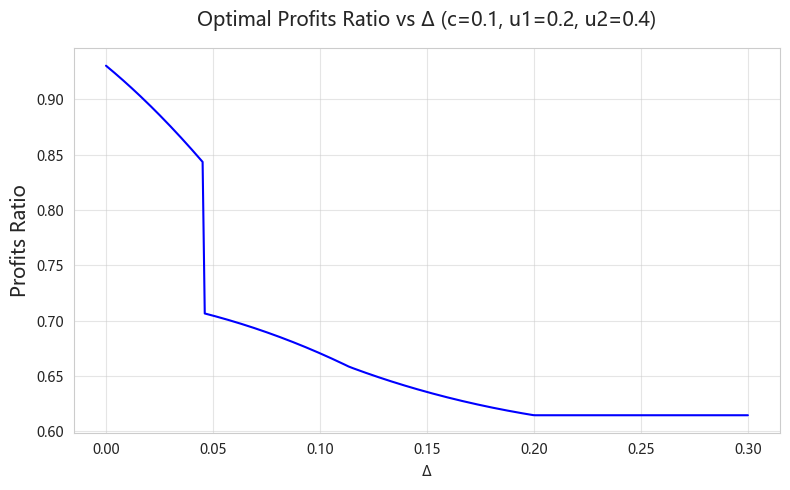

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Profits_ratio, alpha=1, color="blue")
plt.title(f"Optimal Profits Ratio vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Profits Ratio", fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

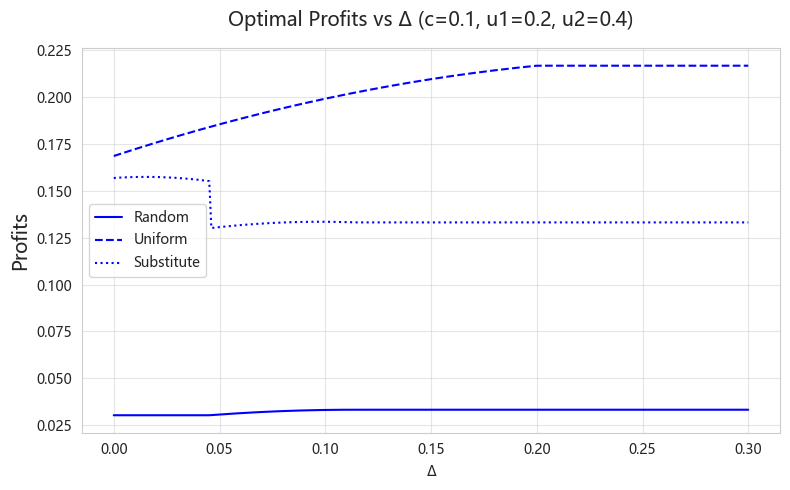

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Profits, alpha=1, color="blue", label="Random")
plt.plot(deltas, Profits_unif, alpha=1, color="blue", linestyle='--', label="Uniform")
plt.plot(deltas, Profits_robust, alpha=1, color="blue", linestyle=':', label="Substitute")
plt.title(f"Optimal Profits vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Profits", fontsize=14)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

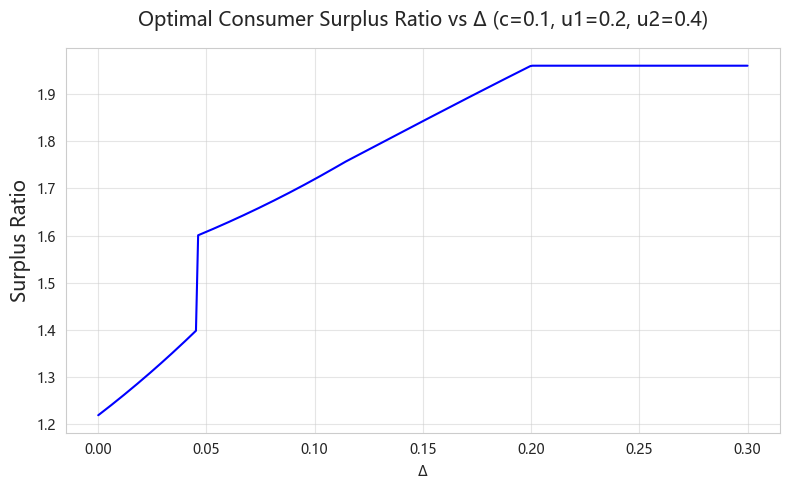

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Surplus_ratio, alpha=1, color="blue")
plt.title(f"Optimal Consumer Surplus Ratio vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Surplus Ratio", fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

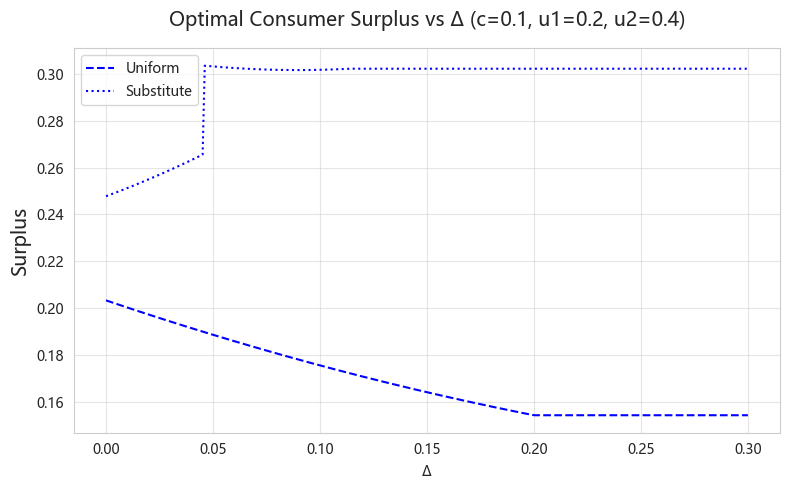

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Surplus_unif, alpha=1, color="blue", linestyle='--', label="Uniform")
plt.plot(deltas, Surplus_robust, alpha=1, color="blue", linestyle=':', label="Substitute")
plt.title(f"Optimal Consumer Surplus vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Surplus", fontsize=14)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

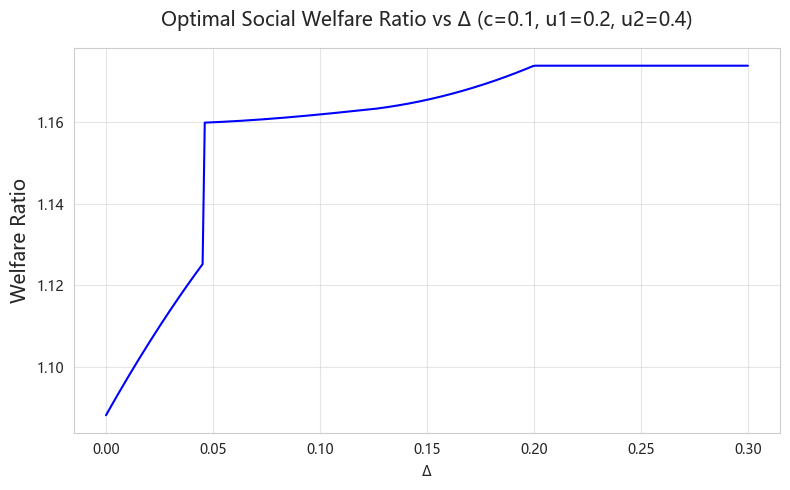

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Trial_ratio, alpha=1, color="blue")
plt.title(f"Optimal Social Welfare Ratio vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Welfare Ratio", fontsize=14)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

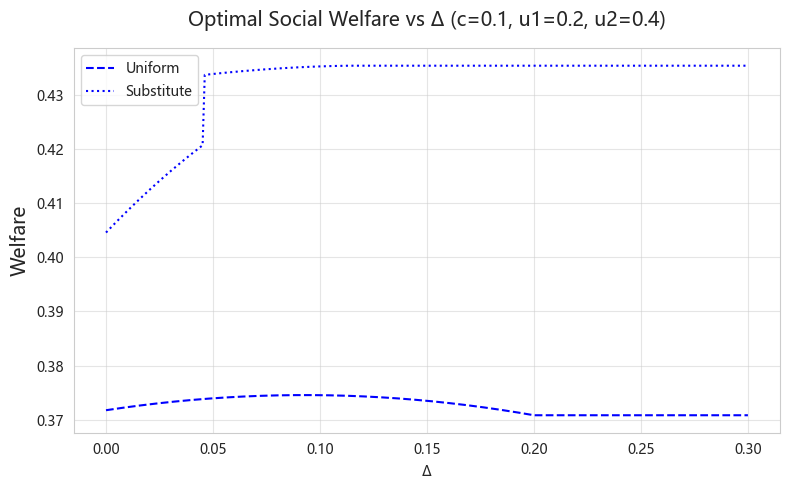

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(deltas, Trial_unif, alpha=1, color="blue", linestyle='--', label="Uniform")
plt.plot(deltas, Trial_robust, alpha=1, color="blue", linestyle=':', label="Substitute")
plt.title(f"Optimal Social Welfare vs Δ (c={c}, u1={u1}, u2={u2})", fontsize=14, pad=16)
plt.xlabel("Δ")
plt.ylabel("Welfare", fontsize=14)
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 跳跃检验

In [7]:
c =0.1
u1=0.2
u2=0.4

p = 1 - sqrt((1-c)*(2-u1-u2)/2)
const_1 = u1 - p
# const_2 = -objective([p, p]) - (sqrt(1-c)-sqrt(1-u2))**2
RT = sqrt(2 - 2*c - u1 + c*u1 - u2 + c*u2)
const_2 = (2 - 2*c - sqrt(2)*RT) * (-2 + sqrt(2)*RT + u1 + u2) / (sqrt(2)*RT)  \
         -(sqrt(1-c)-sqrt(1-u2))**2
const_3 = u1 - 1 + sqrt((1-c)*(1-u2))

print("c:",c,", u1:",u1,", u2:",u2)
print(const_2)            # +  若为正必不跳跃；若不为正必跳跃（等价命题）
print(const_3)            # +  若为正则不跳跃；若跳跃则不为正（逆否命题）

c: 0.1 , u1: 0.2 , u2: 0.4
-0.005207727607601818
-0.06515307716504659


In [5]:
for i in range(100000): 
    c = rd.randint(1, 7)
    u1 = rd.randint(c+1, 8)
    u2 = rd.randint(u1+1, 9) * 0.1
    c *= 0.1
    u1 *= 0.1
    p = 1 - sqrt((1-c)*(2-u1-u2)/2)
    const_1 = u1 - p
    RT = sqrt(2 - 2*c - u1 + c*u1 - u2 + c*u2)
    const_2 = (2 - 2*c - sqrt(2)*RT) * (-2 + sqrt(2)*RT + u1 + u2) / (sqrt(2)*RT)  \
             -(sqrt(1-c)-sqrt(1-u2))**2
    const_3 = u1- 1 + sqrt((1-c)*(1-u2))
    if const_2 < 0 and const_3 >= 0:
        print("ohno核疫卫",c, u1, u2)

# 解跳跃点

In [19]:
# from scipy.optimize import fsolve, root
# from math import sqrt

# def equations(vars):
#     x, y = vars 
#     eq1 = (1-c) * ((1-u1)/(1-x)**2 + (1-u2)/(1-y)**2) - 2
#     eq2 = -objective([x,y]) - eps * (y - x) - (sqrt(1-c)-sqrt(1-u2))**2
#     return [eq1, eq2]


# initial_guess = [(c+u1)/2, (c+u2)/2]

# # 方法3.1: 使用fsolve
# solution1 = fsolve(equations, initial_guess)
# print(f"fsolve解: x = {solution1[0]:.8f}, y = {solution1[1]:.8f}")

# # 方法3.2: 使用root（更强大）
# solution2 = root(equations, initial_guess, method='lm')  # Levenberg-Marquardt
# print(f"root解: x = {solution2.x[0]:.8f}, y = {solution2.x[1]:.8f}")

# print(f"delta: {solution1[1] - solution1[0]:.6f}",)
# print("k-gap:",round((1-c) * ((1-u1)/(1-solution1[0])**2 + (1-u2)/(1-solution1[1])**2) - 2, 8))  # 边际利润为零

# 1. p2* <= μ1

In [20]:
# for i in range(0):
# #     c = rd.random()  # [0, 1)
# #     u1 = c + (1 - c) * rd.random() 
# #     u2 = u1 + rd.random() * (1- (1-u1)**2/(1-c) - u1)  #  *p2 <= u1
#     c = rd.randint(0, 7)
#     u1 = rd.randint(c+1, 8)
#     u2 = rd.randint(u1+1, 9) * 0.1
#     c *= 0.1
#     u1 *= 0.1
#     if u2 > 1- (1-u1)**2/(1-c):
#         continue
        
#     delta = (u2 - c) * rd.random()
#     bounds = [(c, u2), (c, u2)]
#     initial_guess = np.array([(c+u1)/2, (c+u2)/2])

#     result = minimize(objective, initial_guess, 
#                  bounds=bounds, 
#                  constraints=constraints, 
#                  method='SLSQP',
#                  tol=1e-12,           # 收敛容忍度
#                  options={'ftol': 1e-12,  # 函数值变化的容忍度
#                           'eps': 1e-8,    # 有限差分步长
#                           'maxiter': 1000, # 最大迭代次数
#                           'disp': False}   # 显示优化过程信息
#             )

#     optimal_p1, optimal_p2 = result.x
#     max_profit = -result.fun

#     print(f'第{i+1}次试验')
#     print(f"最优p1: {optimal_p1:.6f}")
#     print(f"最优p2: {optimal_p2:.6f}")
#     print(f"p之差: {optimal_p2-optimal_p1:.6f}")
#     print(f"最大利润: {max_profit:.6f}")
# #     print(f"c: {c:.6f}，delta: {delta:.6f}")
# #     print(f"u1: {u1:.6f}, u2: {u2:.6f}")
# #     k1 = 1 - (1-c)*(1-u1)/(1-optimal_p1)**2
# #     k2 = 1 - (1-c)*(1-u2)/(1-optimal_p2)**2
# #     print(f"斜率之和: {k1+k2:.12f}")
    
    
#     plt.figure(figsize=(8, 6))
#     p_values = np.linspace(0, 1, 500)  # 生成数据点
    
#     # 计算r1和r2函数值
#     r1_values = []
#     r2_values = []
#     for p in p_values:
#         if c <= p <= u1:
#             r1 = (p-c)*(u1-p)/(1-p)
#         else:
#             r1 = 0
#         if c <= p <= u2:
#             r2 = (p-c)*(u2-p)/(1-p)
#         else:
#             r2 = 0
#         r1_values.append(r1)
#         r2_values.append(r2)
    
#     # 绘制r1和r2曲线
#     plt.plot(p_values, r1_values, label=f'$r_1(p) = (p-{c:.1f})({u1:.1f}-p)/(1-p)$', linewidth=2, color='blue')
#     plt.plot(p_values, r2_values, label=f'$r_2(p) = (p-{c:.1f})({u2:.1f}-p)/(1-p)$', linewidth=2, color='red')
    
#     # 计算最优点的函数值
#     if c <= optimal_p1 <= u1:
#         optimal_r1 = (optimal_p1-c)*(u1-optimal_p1)/(1-optimal_p1)
#     else:
#         optimal_r1 = 0
    
#     if c <= optimal_p2 <= u2:
#         optimal_r2 = (optimal_p2-c)*(u2-optimal_p2)/(1-optimal_p2)
#     else:
#         optimal_r2 = 0
    
#     # 标记最优点
#     plt.scatter(optimal_p1, optimal_r1, s=100, color='darkblue', marker='o', 
#                label=f'最优p1={optimal_p1:.3f}, r1={optimal_r1:.3f}', zorder=5)
#     plt.scatter(optimal_p2, optimal_r2, s=100, color='darkred', marker='o', 
#                label=f'最优p2={optimal_p2:.3f}, r2={optimal_r2:.3f}', zorder=5)
    
#     # 添加垂直线标记最优价格
#     plt.axvline(x=optimal_p1, color='blue', linestyle='--', alpha=0.7, linewidth=1)
#     plt.axvline(x=optimal_p2, color='red', linestyle='--', alpha=0.7, linewidth=1)

#     # 设置图形属性
#     plt.xlabel('价格 p', fontsize=12)
#     plt.ylabel('利润 r', fontsize=12)
#     plt.title(f'第{i+1}次试验: 利润函数 (c={c:.1f}, u1={u1:.1f}, u2={u2:.1f}, Δ={delta:.3f})', fontsize=18)
#     plt.legend(fontsize=10)
#     plt.grid(True, alpha=0.3)
    
#     # 设置坐标轴范围
#     plt.xlim(0.5*c, (u2+1)/2)
#     plt.ylim(0, max(max(r1_values), max(r2_values)) * 1.1)
      
#     plt.tight_layout()
#     plt.show()

In [21]:
# df = pd.DataFrame({'delta': deltas, 'p1':opt_p1, 'p2':opt_p2, 'max_profit': Profits})
# df.to_csv('result.csv')
# df.head(10)